In [1]:
# LIBS

import os
import pandas as pd
import numpy as np

from pathlib import Path

import warnings
warnings.filterwarnings('ignore') # -> Comente se quiser ver os 'warnings'

import keras

from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, layers, callbacks, models, optimizers
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import TimeSeriesSplit

import seaborn as sns
from pandas.plotting import register_matplotlib_converters
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

register_matplotlib_converters()
sns.set_style("darkgrid")

plt.rc("figure", figsize=(16, 6))
plt.rc("font", size=13)

figure(figsize = (16, 6), dpi = 100)

<Figure size 1600x600 with 0 Axes>

<Figure size 1600x600 with 0 Axes>

### Funções

#### Funções auxiliares para o modelo: incluindo grid search, cross validation e loss function

In [2]:
# Grid search usando validação cruzada em séries temporais (escolhe o com menos val_loss médio)
def grid_search_cv(modelo, units, X_train, learning_rates, y_train, epochs_list, batch_sizes, patiences, model_name):
    best_loss = float('inf')
    best_params = {}
    for lr in learning_rates:
        for epochs in epochs_list:
            for batch_size in batch_sizes:
                for patience in patiences:
                    model = modelo(units, X_train, lr)
                    histories = fit_model_with_cross_validation(model, X_train, y_train, model_name, patience, epochs, batch_size)
                    mean_history = calculate_mean_history(histories)
                    val_loss = min(mean_history['val_loss'])
                    print("Val Loss: ", val_loss, "learning rate: ", lr, "epochs: ",  epochs, "batch_size: " , batch_size, "patience: ", patience)
                    if val_loss < best_loss:
                        best_loss = val_loss
                        best_params = {'learning_rate': lr, 'epochs': epochs, 'batch_size': batch_size, 'patience': patience} 
    print('O modelo '+model_name+ ' tem como melhores parametros os seguintes: learning_rate '+ str(best_params['learning_rate'])+' epochs: '+ str(best_params['epochs'])+' batch_size: '+ str(best_params['batch_size'])+ ' patience: '+ str(best_params['patience']))
    return best_params

# Treina o mesmo modelo em diferentes folds (5) de validação cruzada
def fit_model_with_cross_validation(model, xtrain, ytrain, model_name, patience, epochs, batch_size):
    tscv = TimeSeriesSplit(n_splits=5)
    fold = 1
    histories = []
    for train_index, val_index in tscv.split(xtrain):
        x_train_fold, x_val_fold = xtrain[train_index], xtrain[val_index]
        y_train_fold, y_val_fold = ytrain[train_index], ytrain[val_index]
        early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, min_delta=1e-5)
        history = model.fit(x_train_fold, y_train_fold, epochs=epochs, validation_data=(x_val_fold, y_val_fold), batch_size=batch_size, callbacks=[early_stop], verbose=1)
        print('\n\nTREINAMENTO - Fold', fold, 'do modelo:', model_name)
        histories.append(history)
        fold += 1   
    return histories 

# Calcula curva média de aprenizado de diferentes folds 
def calculate_mean_history(histories):
    mean_history = {'loss': [], 'root_mean_squared_error': [], 'val_loss': [], 'val_root_mean_squared_error': []}
    for fold_history in histories:
        for key in mean_history.keys():
            mean_history[key].append(fold_history.history[key])
    for key, values in mean_history.items():
        max_len = max(len(val) for val in values)
        for i in range(len(values)):
            if len(values[i]) < max_len: #caso em que nao se treina todas as epocas (patience)
                values[i] += [values[i][-1]] * (max_len - len(values[i])) #completa o restante da lista com o ultimo valor obtido
    for key, values in mean_history.items():
        mean_history[key] = [sum(vals) / len(vals) for vals in zip(*values)]
    
    return mean_history

def save_model(model, directory, substring_desejada, modelo):
    if not os.path.exists(directory):
        os.makedirs(directory)
    file_path = os.path.join(directory, f'{substring_desejada +modelo} - final_model.keras')
    model.save(file_path)
    print(f"Modelo salvo como '{file_path}'")




#### Funções do próprio modelo

In [3]:
# Constrói janelas deslizantes (supervisionado):
# para cada posição pega look_back valores como entrada e o próximo como alvo.
# Entradas: X (array 1D ou 2D), look_back. Saída: Xs (shape: nº amostras × look_back × nº_features) e ys (alvo por amostra).
def create_dataset (X, look_back = 3):
    Xs, ys = [], []
    
    for i in range(len(X)-look_back):
        v = X[i:i+look_back]
        Xs.append(v)
        ys.append(X[i+look_back])
        
    return np.array(Xs), np.array(ys)

# Cria um modelo GRU (2 camadas GRU + Dense) 
def create_gru(units, train, learning_rate): 
    model = Sequential() 
    model.add(GRU(units = units, return_sequences = True, input_shape = [train.shape[1], train.shape[2]]))
    model.add(GRU(units = units))   
    model.add(Dense(1))
    model.compile(loss=MeanSquaredError(), optimizer = Adam(learning_rate=learning_rate), metrics=[RootMeanSquaredError()])
    return model

# Cria um modelo LSTM (2 camadas LSTM + Dense)
def create_lstm(units, train, learning_rate): 
    model = Sequential() 
    model.add(LSTM(units = units, return_sequences = True, input_shape = [train.shape[1], train.shape[2]]))
    model.add(LSTM(units = units)) 
    model.add(Dense(1))
    model.compile(loss=MeanSquaredError(), optimizer = Adam(learning_rate=learning_rate), metrics=[RootMeanSquaredError()])
    
    return model

# Treino em cross validation - não está sendo usado 
# def fit_model(model, xtrain, ytrain, model_name, patience, epochs, batch_size ):
#     early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = patience, restore_best_weights=True)
#     history = model.fit(xtrain, ytrain, epochs = epochs, validation_split = 0.2, batch_size = batch_size, shuffle = True, callbacks=[early_stop]) 
#     print('\n\nTREINAMENTO: ' + model_name)
#     return history

# Faz previsões no conjunto de teste, faz inverse_transform para a escala original,
# salva um CSV com colunas Prediction e Test em results/forecast/.
def prediction(model, xtest, ytest, myscaler, model_name, link): 
    FORECAST_DIR = os.path.join('results','forecast')
    if not os.path.exists(FORECAST_DIR):
        os.makedirs(FORECAST_DIR)
        print(f"O diretório '{FORECAST_DIR}' foi criado.")


    prediction = model.predict(xtest) 
    prediction = myscaler.inverse_transform(prediction) 
    # dataframe_prediction = pd.DataFrame(data={'Predições':prediction.flatten()})
    dataframe_prediction = pd.DataFrame(data={'Prediction':prediction.flatten(), 'Test':ytest.flatten()})
    #save_path = os.path.join('..', '..', 'predicoes', f'prediction {model_name} {link}.csv') 
    save_path = os.path.join(FORECAST_DIR, f'prediction {model_name} {link}.csv') 
    dataframe_prediction.to_csv(save_path)
    return prediction


    # #Tenta salvar a fig -> não é bom salvar (ocupa muito espaço no diretório)
    # save_path = os.path.join('..', '..', 'graficos', 'predicoes', 'round_2', 'graficos', link + '.png')

    # #save_path = '../../graficos/predicoes/round_2/graficos/' + link + '.png'
    # try:
    #     plt.savefig(save_path)
    #     print(f"A figura foi salva com sucesso em: {save_path}")
    # except Exception as e:
    #     print(f"Erro ao salvar a figura: {e}")

    # plt.show()

#### Plot de gráficos

In [4]:
# Plota curva de aprendizado média (validação cruzada) - train loss e validation loss
def plot_loss_cv(mean_history, model_name, link):
    epochs = range(1, len(mean_history['loss']) + 1)
    plt.plot(epochs, mean_history['loss'], label='Train Loss')
    plt.plot(epochs, mean_history['val_loss'], label='Validation Loss')
    plt.title('Mean Training and Validation Loss for '+' '+link + ' '+ model_name)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Plota curva de aprendizado média (validação cruzada) - train rmse e validation rmse
def plot_rmse_cv(mean_history):
    epochs = range(1, len(mean_history['root_mean_squared_error']) + 1)
    plt.plot(epochs, mean_history['root_mean_squared_error'], label='Train RMSE')
    plt.plot(epochs, mean_history['val_root_mean_squared_error'], label='Validation RMSE')
    plt.title('Mean Training and Validation RMSE')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()
    plt.show()

# def plot_loss(history, model_name, link):
#      plt.figure(figsize = (15, 6), dpi=100)
#      plt.plot(history.history['loss'])
#      plt.plot(history.history['val_loss'])
#      plt.title('Model Train vs Validation Loss for '+' '+link + ' '+ model_name)
#      plt.ylabel('Loss')
#      plt.xlabel('Epoch')
#      plt.legend(['Train loss', 'Validation loss'], loc='upper right')
     
# def plot_rmse(history, model_name, link):
#      plt.figure(figsize = (15, 6), dpi=100)
#      plt.plot(history.history['rmse'])
#      plt.plot(history.history['val_rmse'])
#      plt.title('Model Train vs RMSE for '+' '+link + ' '+ model_name)
#      plt.ylabel('rmse')
#      plt.xlabel('Epoch')
#      plt.legend(['Train rmse', 'Validation loss'], loc='upper right')

# Plot dados de teste x predição
def plot_future(predictionGRU, predictionLSTM, predictionbiLSTM, y_test, link):
    plt.figure(figsize=(15, 6), dpi=100)
    range_future = len(y_test)
    plt.plot(np.arange(range_future), np.array(y_test), label='Test data')
    plt.plot(np.arange(range_future), np.array(predictionbiLSTM), label='bi-LSTM')
    plt.plot(np.arange(range_future), np.array(predictionGRU), label='GRU')
    plt.plot(np.arange(range_future), np.array(predictionLSTM), label='LSTM')
    # dict_to_dataframe_prediction = {
    #     # "range_future": np.arange(range_future),
    #     f"prediction{model_name}": np.array(prediction.squeeze())
    # }
    
    plt.title('Test data vs prediction for '+ link)
    plt.legend(loc='upper left')
    plt.xlabel('Time')
    plt.ylabel('Mbis/s')
    PLOTS_DIR = os.path.join('results', 'plots')
    if not os.path.exists(PLOTS_DIR):
        os.makedirs(PLOTS_DIR)
        print(f"O diretório '{PLOTS_DIR}' foi criado.")
    save_path = os.path.join(PLOTS_DIR, link + '.png')
    save_path = os.path.normpath(save_path)  

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    try:
        plt.savefig(save_path)
        print(f"A figura foi salva com sucesso em: {save_path}")
    except Exception as e:
        print(f"Erro ao salvar a figura: {e}")
    plt.show()

In [5]:
# Calcula MAE e RMSE para avaliação do modelo
def evaluate_prediction(predictions, actual, model_name):
    errors = predictions - actual
    mse = np.square(errors).mean()
    rmse = np.sqrt(mse)
    nrmse = rmse/ ((np.max(actual))-(np.min(actual)))
    mae = np.abs(errors).mean()
    print(model_name + ':')
    print('Mean Absolute Error: {:.4f}'.format(mae))
    print('Root Mean Square Error: {:.4f}'.format(rmse))
    print('Normalized Root Mean Square Error: {:.4f}%'.format(nrmse*100))
    print('')

    return rmse, mae, nrmse, model_name

# Dados em MegaBits/s e fill
def bits_para_megabits(df, col_vaz):
    df[col_vaz] = df[col_vaz]/1000000
    df[col_vaz] = df[col_vaz].replace(-1, df[col_vaz].mean())
    df[col_vaz] = df[col_vaz].fillna(df[col_vaz].mean())

    return df

# Visualização simples da série temporal     
def visualizacao_series(df, col_vazao, titulo):
    df[col_vazao].plot(figsize=(18,6))
    plt.title(titulo)
    plt.ylabel('Vazao (Mbits/s)')
    plt.legend() 
    plt.show()

# Essa função calcula a média diária dos valores de vazão, é para tratar os valores da RNP
def calcular_media_dia(dataframe, col_data, col_vazao):
    dataframe = dataframe.sort_values(by=[col_data])
    
    dia_atual = None
    valores_para_media = []
    
    def calcular_media_e_substituir():
        if len(valores_para_media) > 0:
            media = np.mean(valores_para_media)
            for idx in indices_para_substituir:
                dataframe.at[idx, col_vazao] = media
    
    indices_para_substituir = []
    
    for idx, row in dataframe.iterrows():
        data = row[col_data]
        vazao = row[col_vazao]
        
        if dia_atual is None:
            dia_atual = data
            valores_para_media = []
            indices_para_substituir = []
        
        if vazao != -1:
            valores_para_media.append(vazao)
        else:
            indices_para_substituir.append(idx)
        
        if data != dia_atual:
            calcular_media_e_substituir()
            dia_atual = data
            valores_para_media = []
            indices_para_substituir = []
    
    calcular_media_e_substituir()
    
    return dataframe

#### Construção do modelo TCN
Essa implementação foi mais para testar rapidamente, não está bem refinada

In [6]:
#TCN
def build_tcn(units, train, learning_rate):
    model = models.Sequential()
    model.add(layers.Conv1D(units, 3, activation='relu', padding='causal', dilation_rate=1, input_shape=[train.shape[1], train.shape[2]]))
    model.add(layers.Dropout(0.2))
    model.add(layers.Conv1D(units, 3, activation='relu', padding='causal', dilation_rate=2))
    model.add(layers.Dropout(0.2))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Flatten())
    model.add(layers.Dense(units, activation='relu'))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(1)) 
    #optimizer = optimizers.Adam(learning_rate=learning_rate)
    #model.compile(optimizer=optimizer, loss='mse')  # Para regressão. Para classificação, use 'categorical_crossentropy'.
    model.compile(loss = MeanSquaredError(), optimizer = Adam(learning_rate=learning_rate), metrics = [RootMeanSquaredError()])
    return model

# Cria um modelo bi-LSTM (2 camadas bi-LSTM + Dense)
def create_bi_lstm(units, train, learning_rate):
    model = Sequential()
    model.add(Bidirectional(LSTM(units=units, return_sequences=True), input_shape=[train.shape[1], train.shape[2]]))
    model.add(Bidirectional(LSTM(units=units)))
    model.add(Dense(1))
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate), metrics=[RootMeanSquaredError()])

    return model

### Execução da predição em si
Esse código é feito para rodar bi-lstm, lstm e gru nos datasets da RNP (MonIpê) que tinham as colunas de Timestamp e Throughput (vazão em bits/s) pré-processados com diversas técncias de imputação, nos subdiretórios correspondentes às técnicas de imputação, no diretório deses datasets. 

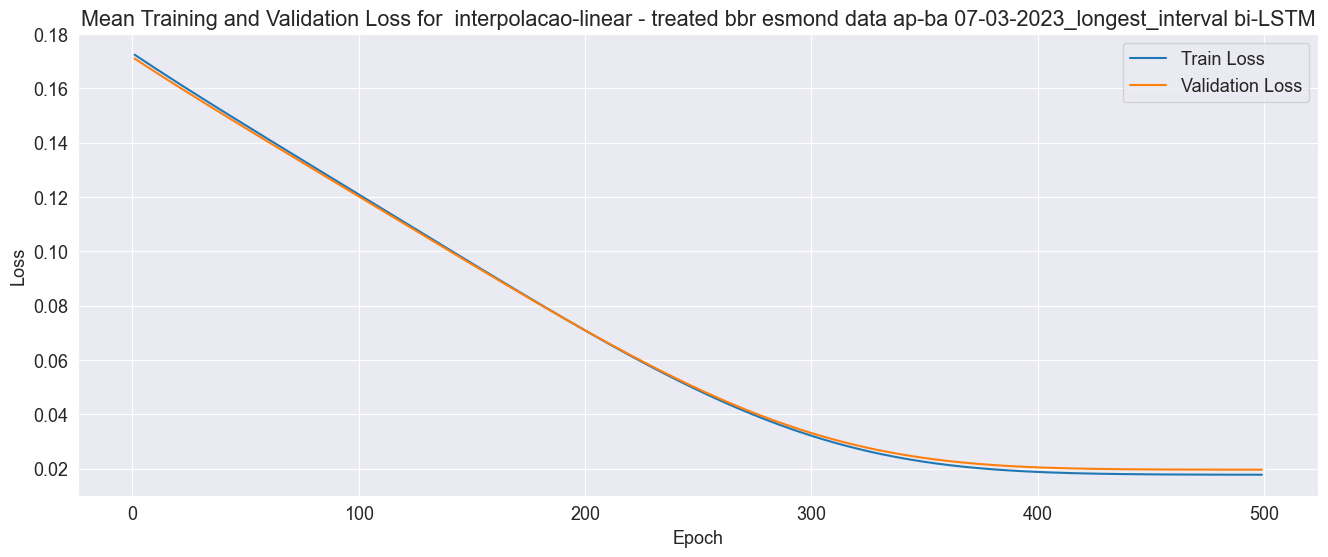

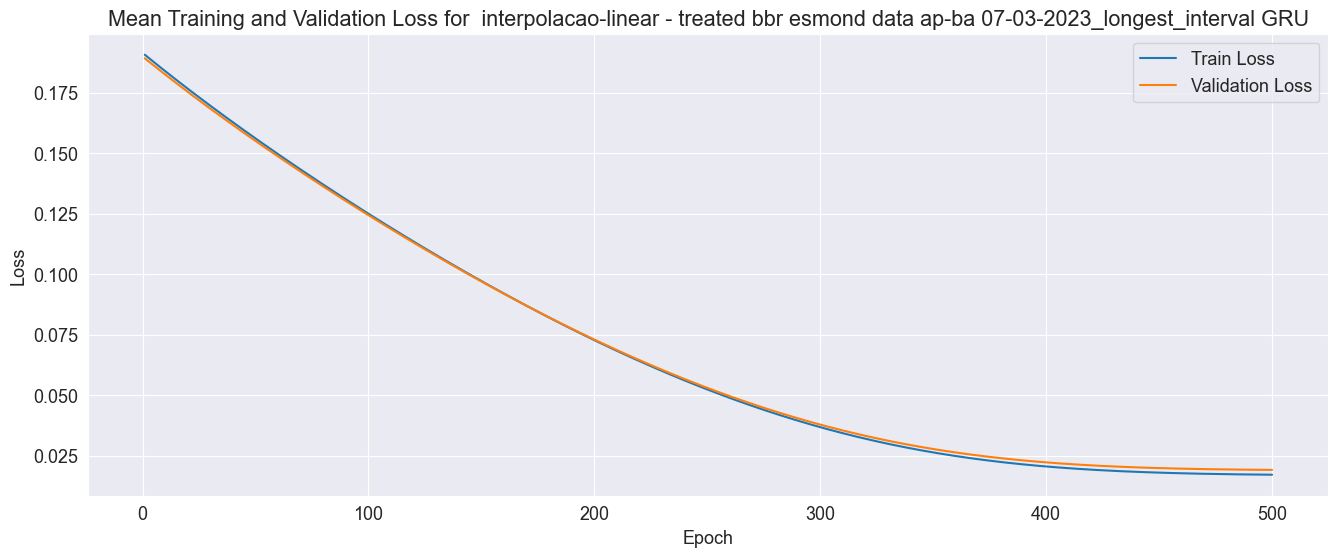

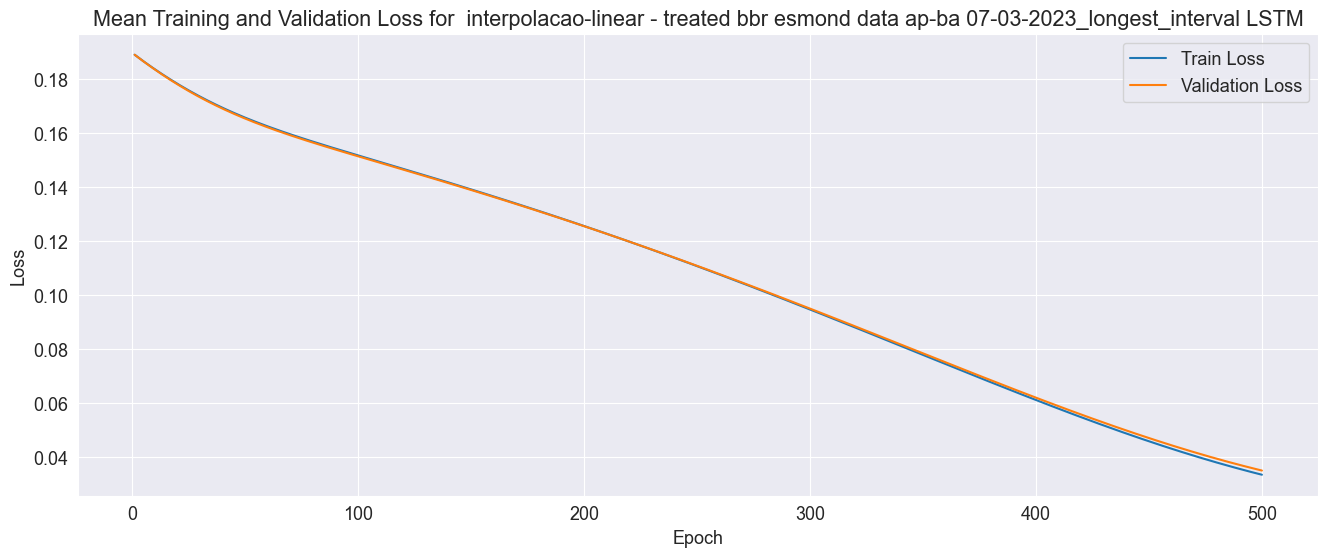

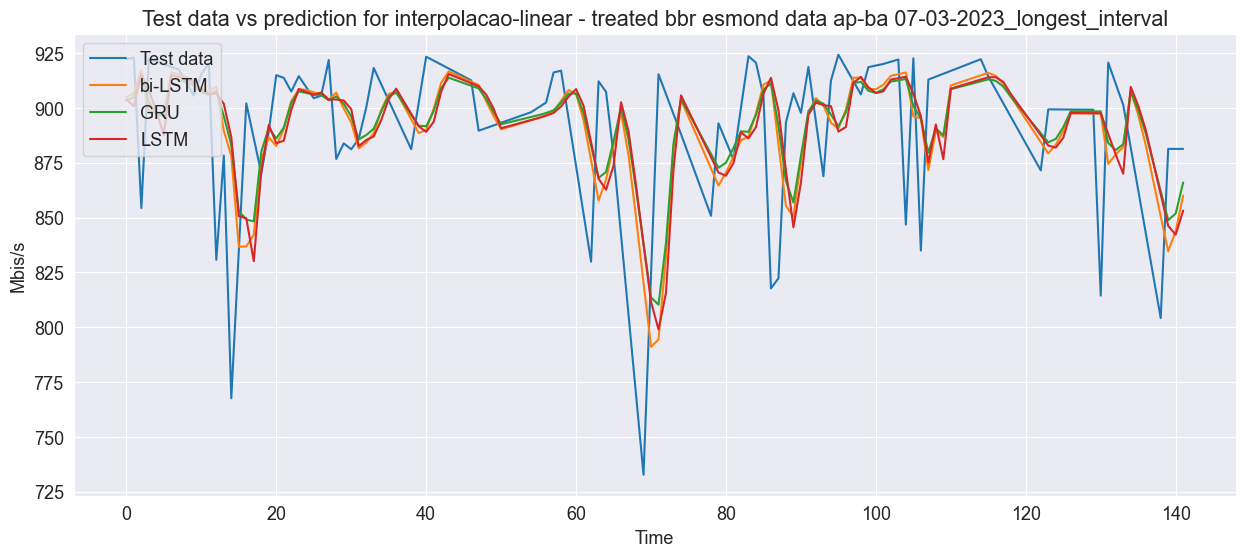

KeyboardInterrupt: 

In [7]:
#salvando as saidas em um arquivo externo para analise 
import sys

# Redirecionar saída padrão para um arquivo com codificação utf-8
orig_stdout = sys.stdout
f = open('training_output.txt', 'w', encoding='utf-8')
sys.stdout = f

# Model Trainnig and Prediction
import os
import re
#treinamento e predição

diretorio_raiz = os.path.join('data', 'imputed-rnp-throughput') 

if not os.path.exists(diretorio_raiz):
    print(f"O diretório '{diretorio_raiz}' não existe.")

evaluation = {}

# Itere pelos diretórios e subdiretórios
for pasta_raiz, subpastas, arquivos in os.walk(diretorio_raiz):
    for arquivo in arquivos:
        # Verifique se o arquivo é um arquivo CSV
        if arquivo.endswith('.csv'):
            # Construa o caminho completo para o arquivo
            caminho_arquivo = os.path.join(pasta_raiz, arquivo)
            # print(caminho_arquivo)

        try:
                # Título parser
                # partes = caminho_arquivo.split("\\")
                # if len(partes) >= 2:
                # #     substring_desejada = "/".join(partes[1:])  # Acesse as partes a partir da segunda e as una com barras invertidas
                # partes = caminho_arquivo.split(os.sep)
                # #partes = caminho_arquivo.split("/")
                # substring_desejada = partes[4] + ' - ' + partes[5]  # Acesse as partes a partir da segunda e as una com barras invertidas

                p = Path(caminho_arquivo)
                folder = p.parent.name                 # nome da pasta imediata (ex.: 'svd')
                file_stem = p.stem                     # nome do arquivo sem extensão
                substring_desejada = f"{folder} - {file_stem}"
                
                #df = pd.read_csv(caminho_arquivo, index_col='Data')
                df = pd.read_csv(caminho_arquivo, index_col='Timestamp')
                if '0' in df.columns:
                    df = df.drop('0', axis=1)
                
                # Regularizar o dataset para megabits/s
                bits_para_megabits(df, 'Throughput')

                # Visualização das séries
                # visualizacao_series(df, 'Vazao', substring_desejada)

                # print('média dataset: '+ str(df['Vazao'].mean()))
                
                # print(substring_desejada)

                print('###################### '+substring_desejada+' ##########################')

                #PREDICAO
                tamanho = int(len(df.index) * 0.8)

                # Set random seed to get the same result after each time running the code
                tf.random.set_seed(7)

                # Split train data and test data
                train_size = tamanho

                # train_data = df.WC.loc[:train_size] -----> it gives a series
                # Do not forget use iloc to select a number of rows
                train_data = df[:train_size]
                test_data = df[train_size:]
                
                # Criar uma instância do MinMaxScaler
                train_data = train_data['Throughput'].values.reshape(-1, 1)
                test_data = test_data['Throughput'].values.reshape(-1, 1)

                scaler = MinMaxScaler().fit(train_data)

                train_scaled = scaler.transform(train_data)
                test_scaled = scaler.transform(test_data)

                X_train, y_train = create_dataset(train_scaled)
                X_test, y_test = create_dataset(test_scaled)

                #grid search para encontrar os melhores parametros
                list_lr = [0.00001] 
                list_epochs = [100, 300, 500] 
                list_bs = [32, 64, 128] 
                list_pat = [5]

                #caminho para salvar o modelo:
                caminho_modelo_salvo = '../../modelo_salvo'
                best_params_bilstm = grid_search_cv(create_bi_lstm, 64, X_train, list_lr, y_train, list_epochs, list_bs, list_pat, 'bi-lstm')
                best_params_gru = grid_search_cv(create_gru, 64, X_train, list_lr, y_train, list_epochs, list_bs, list_pat, 'gru')
                best_params_lstm = grid_search_cv(create_lstm, 64, X_train, list_lr, y_train, list_epochs, list_bs, list_pat, 'lstm')
                #tendo os melhores parametros, eu crio o modelo e treino ele com os melhores
                model_bilstm = create_bi_lstm(64, X_train, best_params_bilstm['learning_rate'])
                model_gru = create_gru(64, X_train, best_params_gru['learning_rate'])
                model_lstm = create_lstm(64, X_train, best_params_lstm['learning_rate'])

                prev_history_bilstm = fit_model_with_cross_validation(model_bilstm, X_train, y_train, 'bilstm', best_params_bilstm['patience'], best_params_bilstm['epochs'], best_params_bilstm['batch_size'])
                prev_history_gru = fit_model_with_cross_validation(model_gru, X_train, y_train, 'gru', best_params_gru['patience'], best_params_gru['epochs'], best_params_gru['batch_size'])
                prev_history_lstm = fit_model_with_cross_validation(model_lstm, X_train, y_train, 'lstm', best_params_lstm['patience'], best_params_lstm['epochs'], best_params_lstm['batch_size'])
                history_bilstm = calculate_mean_history(prev_history_bilstm)
                history_gru = calculate_mean_history(prev_history_gru)
                history_lstm = calculate_mean_history(prev_history_lstm)
                
                #salvando o modelo
                save_model(model_bilstm, caminho_modelo_salvo, substring_desejada, 'bi-LSTM')
                save_model(model_gru, caminho_modelo_salvo, substring_desejada, 'GRU')
                save_model(model_lstm, caminho_modelo_salvo, substring_desejada, 'LSTM')


                # Transform data back to original data space
                y_test = scaler.inverse_transform(y_test)
                y_train = scaler.inverse_transform(y_train)

                prediction_bilstm = prediction(model_bilstm, X_test, y_test, scaler, 'bi-LSTM', link = substring_desejada)
                prediction_gru = prediction(model_gru, X_test, y_test, scaler, 'GRU', link = substring_desejada)
                prediction_lstm = prediction(model_lstm, X_test, y_test, scaler, 'LSTM', link=substring_desejada)

                #plot_loss (history_gru, 'GRU', substring_desejada)
                #plot_loss (history_lstm, 'LSTM', substring_desejada)
                
                plot_loss_cv(history_bilstm, 'bi-LSTM', substring_desejada)
                plot_loss_cv(history_gru, 'GRU',substring_desejada )
                plot_loss_cv(history_lstm, 'LSTM', substring_desejada)
                

                plot_future(prediction_gru, prediction_lstm, prediction_bilstm, y_test, link = substring_desejada)
                # lstm_forecast = plot_future(prediction_lstm, 'LSTM', y_test, link = substring_desejada)

                # plot_future_comparing_train_test (X_train, prediction_gru[1], 'GRU', substring_desejada)
                # plot_future_comparing_train_test (X_train, prediction_lstm[1], 'LSTM', substring_desejada)
                bilstm_evaluation = evaluate_prediction(prediction_bilstm, y_test, 'bi-LSTM')
                gru_evaluation = evaluate_prediction(prediction_gru, y_test, 'GRU')
                lstm_evaluation = evaluate_prediction(prediction_lstm, y_test, 'LSTM')


                # guardar valores de avaliação
                chave_bilstm = f"{substring_desejada}, {bilstm_evaluation[3]}"  # Crie uma chave baseada no valor de i
                tupla = (bilstm_evaluation[0], bilstm_evaluation[1], bilstm_evaluation[2])  # Crie uma tupla com valores baseados em i
                evaluation[chave_bilstm] = tupla  # Adicione a chave e a tupla ao dicionário

                chave_gru = f"{substring_desejada}, {gru_evaluation[3]}"  # Crie uma chave baseada no valor de i
                tupla = (gru_evaluation[0], gru_evaluation[1], gru_evaluation[2])  # Crie uma tupla com valores baseados em i
                evaluation[chave_gru] = tupla  # Adicione a chave e a tupla ao dicionário

                chave_lstm = f"{substring_desejada}, {lstm_evaluation[3]}"  # Crie uma chave baseada no valor de i
                tupla = (lstm_evaluation[0], lstm_evaluation[1], lstm_evaluation[2])  # Crie uma tupla com valores baseados em i
                evaluation[chave_lstm] = tupla  # Adicione a chave e a tupla ao dicionário

                # print(evaluation+'\n\n')
                    
        except pd.errors.EmptyDataError:
            # Arquivo vazio
            print(f"Arquivo: {arquivo} - O arquivo está vazio, subpasta: {pasta_raiz}")
        except Exception as e:
            # Tratar outras exceções, se necessário
                print(f"Arquivo: {arquivo}, subpasta: {pasta_raiz} - Erro: {str(e)}")

    
        novo_dicionario = {}
        import json
        
        # Itere pelo dicionário original
        for chave, valores in evaluation.items():
            valor1, valor2, valor3 = valores  # Desempacote os valores da tupla
            novo_dicionario[chave] = {'RMSE': valor1, 'MAE': valor2, 'NRMSE': valor3}

        json_path = os.path.join('results','evaluation_rmse_mae_2.json')
        with open(json_path, 'w') as arquivo:
            json.dump(novo_dicionario, arquivo, indent=4)

        # with open('../../graficos/predicoes/round_2/evaluation_rmse_mae_2.json', 'w') as arquivo:
        #     json.dump(novo_dicionario, arquivo, indent=4)

    # with open('..\\..\\graficos\\predicoes\\round_2\\evaluation_rmse_mae_2.json', 'w') as arquivo:
    #     json.dump(novo_dicionario, arquivo, indent=4)